# Late Fusion — FER + Eye Tracking

Combines predictions from two saved models:
- **FER model** (`fer_best.pth`) — trained on 6-channel stacked images (original + occluded)
- **Eye Tracking model** (`eye_best.pkl`) — trained on MediaPipe eye metrics

**Fusion strategy:** Weighted average of softmax probabilities  
**Output:** Final emotion prediction per image

## Cell 1 — Install & Mount

In [5]:
!pip install timm mediapipe scikit-learn joblib --quiet

# from google.colab import drive
# drive.mount('/content/drive')

import os
FER_MODELS_DIR = 'Autism emotion recognition dataset/models'
EYE_MODELS_DIR     = 'Autism emotion recognition dataset/results/Eye/Eye_models'
OUTPUT_DIR = 'Autism emotion recognition dataset/results/lateFusion'
TEST_DIR   = 'Autism emotion dataset/test'


os.makedirs(OUTPUT_DIR, exist_ok=True)


ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: '/opt/jupyterhub/lib/python3.12/site-packages/nvidia'
Check the permissions.


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Cell 2 — Imports

In [6]:
import json
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import cv2
import timm
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python.vision import face_landmarker
from mediapipe.tasks.python.vision.core.vision_task_running_mode import VisionTaskRunningMode

from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## Load Configs from Both Models

In [7]:
# Load FER config
with open(os.path.join(FER_MODELS_DIR, 'fer_model_config.json')) as f:
    fer_cfg = json.load(f)

# Load Eye Tracking config
with open(os.path.join(EYE_MODELS_DIR, 'eye_model_config.json')) as f:
    eye_cfg = json.load(f)

print('FER Config')
print(f'  Best model : {fer_cfg["best_model"]}')
print(f'  Test acc   : {fer_cfg["best_test_acc"]:.4f}')
print(f'  Classes    : {fer_cfg["emotions"]}')

print('\n Eye Tracking Config ')
print(f'  Best model : {eye_cfg["best_model"]}')
print(f'  Val acc    : {eye_cfg["best_val_acc"]:.4f}')
print(f'  Features   : {len(eye_cfg["features"])} features')

# Shared constants
EMOTIONS    = fer_cfg['emotions']
CLASS_MAP   = fer_cfg['class_map']
NUM_CLASSES = fer_cfg['num_classes']
print(f'\nShared emotions: {EMOTIONS}')

FER Config
  Best model : resnet18
  Test acc   : 0.6239
  Classes    : ['anger', 'fear', 'joy', 'Natural', 'sadness', 'surprise']

 Eye Tracking Config 
  Best model : Random Forest
  Val acc    : 0.4808
  Features   : 34 features

Shared emotions: ['anger', 'fear', 'joy', 'Natural', 'sadness', 'surprise']


## Download MediaPipe Model

In [8]:
MP_MODEL_PATH = 'face_landmarker.task'
if not os.path.exists(MP_MODEL_PATH):
    print('Downloading...')
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task',
        MP_MODEL_PATH
    )
    print('Done')
else:
    print('Already present.')

Already present.


##  Rebuild FER Model Architecture & Load Weights

In [9]:


class MultiScaleViT(nn.Module):

    def __init__(self, num_classes=6, in_chans=6, pretrained=False):
        super().__init__()
        self.backbone   = timm.create_model('vit_base_patch16_224', pretrained=pretrained,num_classes=0, in_chans=in_chans, img_size=224)
        embed_dim       = self.backbone.embed_dim
        self.down2      = nn.AdaptiveAvgPool2d((112, 112))
        self.down4      = nn.AdaptiveAvgPool2d((56, 56))
        self.up_from_112 = nn.Upsample(size=(224, 224), mode='bilinear', align_corners=False)
        self.up_from_56  = nn.Upsample(size=(224, 224), mode='bilinear', align_corners=False)
        self.fusion = nn.Sequential(
            nn.LayerNorm(embed_dim * 3),
            nn.Linear(embed_dim * 3, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward_one_scale(self, x):
        return self.backbone(x)

    def forward(self, x):
        feat_224 = self.forward_one_scale(x)
        feat_112 = self.forward_one_scale(self.up_from_112(self.down2(x)))
        feat_56  = self.forward_one_scale(self.up_from_56(self.down4(x)))
        return self.fusion(torch.cat([feat_224, feat_112, feat_56], dim=1))

def build_fer_model(model_name, num_classes=6):
    """Rebuild the FER model architecture matching what was trained."""
    if model_name == 'resnet18':
        m = models.resnet18(weights=None)
        m.conv1 = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)
        m.fc    = nn.Linear(m.fc.in_features, num_classes)

    elif model_name == 'resnet50':
        m = models.resnet50(weights=None)
        m.conv1 = nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3, bias=False)
        m.fc    = nn.Linear(m.fc.in_features, num_classes)

    elif model_name == 'vit':
        m = timm.create_model('vit_base_patch32_224', pretrained=False,num_classes=num_classes, in_chans=6)

    elif model_name == 'multiscale_vit':
        m = MultiScaleViT(num_classes=num_classes, in_chans=6, pretrained=False)
    else:
        raise ValueError(f'Unknown model: {model_name}')

    return m.to(DEVICE)


# Load the best FER model
fer_model = build_fer_model(fer_cfg['best_model'], num_classes=NUM_CLASSES)
fer_model.load_state_dict(torch.load(
    os.path.join(FER_MODELS_DIR, 'fer_best.pth'), map_location=DEVICE
))
fer_model.eval()
print(f'FER model loaded: {fer_cfg["best_model"]}')

FER model loaded: resnet18


## Load Eye Tracking Model

In [10]:
eye_model = joblib.load(os.path.join(EYE_MODELS_DIR, 'eye_best.pkl'))

# Load scaler only if SVM was the best eye model
eye_scaler = None
if eye_cfg.get('needs_scaler', False):
    eye_scaler = joblib.load(os.path.join(EYE_MODELS_DIR, 'eye_svm_scaler.pkl'))
    print('Eye scaler loaded (SVM model).')

EYE_FEATURES = eye_cfg['features']   # exact feature order the eye model expects
print(f'Eye model loaded : {eye_cfg["best_model"]}')
print(f'Features         : {len(EYE_FEATURES)}')

Eye model loaded : Random Forest
Features         : 34


##Eye Metric Extraction (MediaPipe)

In [11]:
# ── MediaPipe landmark constants ───────────────────────────────
LEFT_EYE_INDICES   = [33, 7, 163, 144, 145, 153, 154, 155, 133, 173, 157, 158, 159, 160, 161, 246]
RIGHT_EYE_INDICES  = [362, 382, 381, 380, 374, 373, 390, 249, 263, 466, 388, 387, 386, 385, 384, 398]
LEFT_EYE_VERTICAL_1  = [159, 145]; LEFT_EYE_VERTICAL_2  = [158, 153]; LEFT_EYE_HORIZONTAL  = [33, 133]
RIGHT_EYE_VERTICAL_1 = [386, 374]; RIGHT_EYE_VERTICAL_2 = [385, 380]; RIGHT_EYE_HORIZONTAL = [362, 263]
LEFT_IRIS_INDICES  = [468, 469, 470, 471, 472]
RIGHT_IRIS_INDICES = [473, 474, 475, 476, 477]
GAZE_DIRS = ['centre', 'left', 'right', 'up', 'down']
STATIC_FEATURES = [
    'left_ear', 'right_ear', 'avg_ear', 'eye_openness_pct',
    'left_relative_pupil_x', 'left_relative_pupil_y',
    'right_relative_pupil_x', 'right_relative_pupil_y',
    'left_eye_width', 'left_eye_height',
    'right_eye_width', 'right_eye_height',
]

def calculate_distance(p1, p2):
    return np.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

def calculate_ear(v1, v2, h):
    return (calculate_distance(*v1) + calculate_distance(*v2)) / (2.0 * calculate_distance(*h) + 1e-6)

def get_eye_metrics(landmarks, image_width, image_height,eye_indices, v1_idx, v2_idx, h_idx, iris_indices=None):
    pts = np.array([(int(landmarks[i].x*image_width), int(landmarks[i].y*image_height))
                    for i in eye_indices])
    eye_left, eye_right = pts[:,0].min(), pts[:,0].max()
    eye_top,  eye_bottom = pts[:,1].min(), pts[:,1].max()
    eye_width    = eye_right - eye_left
    eye_height   = eye_bottom - eye_top
    eye_center_x = (eye_left + eye_right) / 2
    eye_center_y = (eye_top  + eye_bottom) / 2
    def lm(i): return (landmarks[i].x*image_width, landmarks[i].y*image_height)
    ear = calculate_ear([lm(v1_idx[0]), lm(v1_idx[1])],
                        [lm(v2_idx[0]), lm(v2_idx[1])],
                        [lm(h_idx[0]),  lm(h_idx[1])])
    pupil_x, pupil_y = eye_center_x, eye_center_y
    if iris_indices and len(landmarks) > max(iris_indices):
        pupil_x = landmarks[iris_indices[0]].x * image_width
        pupil_y = landmarks[iris_indices[0]].y * image_height
    return {
        'pupil_x': pupil_x, 'pupil_y': pupil_y,
        'relative_pupil_x': (pupil_x - eye_center_x) / (eye_width  / 2 + 1e-6),
        'relative_pupil_y': (pupil_y - eye_center_y) / (eye_height / 2 + 1e-6),
        'eye_center_x': eye_center_x, 'eye_center_y': eye_center_y,
        'eye_width': eye_width, 'eye_height': eye_height,
        'eye_aspect_ratio': ear,
    }

def derive_gaze(left_m, right_m):
    avg_x = (left_m['relative_pupil_x'] + right_m['relative_pupil_x']) / 2
    avg_y = (left_m['relative_pupil_y'] + right_m['relative_pupil_y']) / 2
    if abs(avg_x) < 0.15 and abs(avg_y) < 0.15: return 'centre'
    if abs(avg_x) >= abs(avg_y): return 'right' if avg_x > 0 else 'left'
    return 'down' if avg_y > 0 else 'up'


# Initialise MediaPipe landmarker
base_options = python.BaseOptions(model_asset_path=MP_MODEL_PATH)
mp_options   = face_landmarker.FaceLandmarkerOptions(
    base_options=base_options, running_mode=VisionTaskRunningMode.IMAGE
)
mp_landmarker = face_landmarker.FaceLandmarker.create_from_options(mp_options)
print('MediaPipe landmarker ready.')


def extract_eye_features_from_image(img_path):
    """
    Given an image path, extract and engineer all eye features.
    Returns a numpy array matching EYE_FEATURES order, or None if no face found.
    """
    img = cv2.imread(str(img_path))
    if img is None: return None
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    result = mp_landmarker.detect(mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb))
    if not result.face_landmarks: return None

    lm  = result.face_landmarks[0]
    lm_ = get_eye_metrics(lm, w, h, LEFT_EYE_INDICES,
                          LEFT_EYE_VERTICAL_1, LEFT_EYE_VERTICAL_2,
                          LEFT_EYE_HORIZONTAL, LEFT_IRIS_INDICES)
    rm_ = get_eye_metrics(lm, w, h, RIGHT_EYE_INDICES,
                          RIGHT_EYE_VERTICAL_1, RIGHT_EYE_VERTICAL_2,
                          RIGHT_EYE_HORIZONTAL, RIGHT_IRIS_INDICES)
    avg_ear   = (lm_['eye_aspect_ratio'] + rm_['eye_aspect_ratio']) / 2
    gaze_dir  = derive_gaze(lm_, rm_)

    # Base row dict
    row = {
        'left_ear': lm_['eye_aspect_ratio'], 'right_ear': rm_['eye_aspect_ratio'],
        'avg_ear': avg_ear, 'eye_openness_pct': min(100.0, (avg_ear / 0.30) * 100),
        'left_relative_pupil_x': lm_['relative_pupil_x'],
        'left_relative_pupil_y': lm_['relative_pupil_y'],
        'right_relative_pupil_x': rm_['relative_pupil_x'],
        'right_relative_pupil_y': rm_['relative_pupil_y'],
        'left_eye_width': lm_['eye_width'], 'left_eye_height': lm_['eye_height'],
        'right_eye_width': rm_['eye_width'], 'right_eye_height': rm_['eye_height'],
    }

    # Gaze dummies
    for d in GAZE_DIRS:
        row[f'gaze_{d}'] = 1 if gaze_dir == d else 0

    # Engineered features (must match eye tracking notebook)
    row['ear_asymmetry']        = row['left_ear'] - row['right_ear']
    row['ear_asymmetry_abs']    = abs(row['ear_asymmetry'])
    row['ear_ratio_lr']         = row['left_ear'] / (row['right_ear'] + 1e-6)
    row['left_eye_aspect']      = row['left_eye_height']  / (row['left_eye_width']  + 1e-6)
    row['right_eye_aspect']     = row['right_eye_height'] / (row['right_eye_width'] + 1e-6)
    row['eye_aspect_asymmetry'] = row['left_eye_aspect']  - row['right_eye_aspect']
    row['eye_width_asymmetry']  = row['left_eye_width']   - row['right_eye_width']
    row['eye_height_asymmetry'] = row['left_eye_height']  - row['right_eye_height']
    row['avg_gaze_x']           = (row['left_relative_pupil_x'] + row['right_relative_pupil_x']) / 2
    row['avg_gaze_y']           = (row['left_relative_pupil_y'] + row['right_relative_pupil_y']) / 2
    row['gaze_magnitude']       = np.sqrt(row['avg_gaze_x']**2 + row['avg_gaze_y']**2)
    row['pupil_x_divergence']   = row['left_relative_pupil_x'] - row['right_relative_pupil_x']
    row['pupil_y_divergence']   = row['left_relative_pupil_y'] - row['right_relative_pupil_y']
    row['ear_x_gaze_mag']       = row['avg_ear'] * row['gaze_magnitude']
    row['ear_x_gaze_y']         = row['avg_ear'] * row['avg_gaze_y']
    row['is_wide_open']         = 1 if row['avg_ear'] > 0.30 else 0
    row['is_squinting']         = 1 if row['avg_ear'] < 0.22 else 0

    # Return in the exact feature order the eye model was trained on
    return np.array([row.get(f, 0.0) for f in EYE_FEATURES], dtype=np.float32)

print('Eye feature extractor ready.')

MediaPipe landmarker ready.
Eye feature extractor ready.


W0000 00:00:1775490939.409573   41864 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1775490939.439481   41864 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1775490939.501711   41934 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 590.44.01), renderer: Quadro RTX 6000/PCIe/SSE2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1775490939.518169   41874 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1775490939.532653   41893 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


##FER Occlusion (needed to build 6-channel input)

In [12]:
class FacialRegionOcclusion:
    REGION_INDICES = {
        'left_eye':  [33, 160, 158, 133, 153, 144],
        'right_eye': [362, 385, 387, 263, 373, 380],
        'nose':      [1, 2, 98, 327, 168, 195],
    }
    def __init__(self, regions=['left_eye', 'right_eye', 'nose'],
                 occlusion_value=0, model_path=MP_MODEL_PATH):
        self.regions = regions
        self.occlusion_value = occlusion_value
        self.region_indices  = self.REGION_INDICES
        base_options = python.BaseOptions(model_asset_path=model_path)
        options = face_landmarker.FaceLandmarkerOptions(
            base_options=base_options, running_mode=VisionTaskRunningMode.IMAGE)
        self.landmarker = face_landmarker.FaceLandmarker.create_from_options(options)

    def get_landmarks(self, image_np):
        if image_np.dtype != np.uint8:
            image_np = image_np.astype(np.uint8)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_np)
        results  = self.landmarker.detect(mp_image)
        if not results.face_landmarks: return None
        lms = results.face_landmarks[0]
        return [(int(lm.x * image_np.shape[1]), int(lm.y * image_np.shape[0])) for lm in lms]

    def occlude_region(self, image_np, landmarks, region_name):
        indices  = self.region_indices[region_name]
        points   = np.array([landmarks[i] for i in indices], dtype=np.int32)
        center_x = int(np.mean([p[0] for p in points]))
        center_y = int(np.mean([p[1] for p in points]))
        h, w = image_np.shape[:2]
        box_h, box_w = int(h * 0.25), int(w * 0.25)
        top    = max(0, center_y - box_h // 2)
        bottom = min(h, top + box_h)
        left   = max(0, center_x - box_w // 2)
        right  = min(w, left + box_w)
        image_np[top:bottom, left:right] = int(self.occlusion_value * 255)
        return image_np

    def __call__(self, pil_image):
        image_np  = np.array(pil_image)
        landmarks = self.get_landmarks(image_np)
        if landmarks is None: return pil_image
        occluded = image_np.copy()
        for region in self.regions:
            occluded = self.occlude_region(occluded, landmarks, region)
        return Image.fromarray(occluded)


occluder = FacialRegionOcclusion(regions=['left_eye', 'right_eye', 'nose'])

fer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def build_fer_input(img_path):
    """Build 6-channel stacked tensor for FER model."""
    pil = Image.open(str(img_path)).convert('RGB')
    original = fer_transform(pil)
    occ_pil  = occluder(pil)
    occluded = fer_transform(occ_pil)
    return torch.cat([original, occluded], dim=0).unsqueeze(0)  # (1, 6, 224, 224)

print('FER input builder ready.')

W0000 00:00:1775490939.547899   42035 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1775490939.553432   42035 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1775490939.594424   42075 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 590.44.01), renderer: Quadro RTX 6000/PCIe/SSE2
W0000 00:00:1775490939.597746   42041 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


FER input builder ready.


W0000 00:00:1775490939.611448   42057 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


## Fusion Inference Function
---
You control the blend with `fer_weight` and `eye_weight`.  
A good starting point is proportional to each model's accuracy.

In [13]:
# ── Fusion weights — adjust based on each model's accuracy ────
# Higher weight = more influence on final prediction
FER_WEIGHT = fer_cfg['best_test_acc']              # e.g. 0.65
EYE_WEIGHT = eye_cfg['best_val_acc']               # e.g. 0.45
total      = FER_WEIGHT + EYE_WEIGHT
FER_WEIGHT /= total    # normalise so they sum to 1
EYE_WEIGHT /= total

print(f'FER weight : {FER_WEIGHT:.3f}')
print(f'Eye weight : {EYE_WEIGHT:.3f}')


def fuse_predict(img_path):
    """
    Run late fusion for a single image.
    Returns (predicted_emotion, fer_proba, eye_proba, fused_proba).
    Returns None if either modality fails.
    """
    # FER branch
    try:
        fer_input = build_fer_input(img_path).to(DEVICE)
        with torch.no_grad():
            fer_logits = fer_model(fer_input)
            fer_proba  = torch.softmax(fer_logits, dim=1).cpu().numpy()[0]  # (6,)
    except Exception as e:
        print(f'FER failed for {img_path}: {e}')
        fer_proba = None

    # Eye tracking branch
    try:
        eye_feats = extract_eye_features_from_image(img_path)
        if eye_feats is None:
            eye_proba = None
        else:
            X = eye_feats.reshape(1, -1)
            if eye_scaler is not None:
                X = eye_scaler.transform(X)
            eye_proba = eye_model.predict_proba(X)[0]   # (6,)
    except Exception as e:
        print(f'Eye failed for {img_path}: {e}')
        eye_proba = None

    # Fuse
    if fer_proba is not None and eye_proba is not None:
        fused = (FER_WEIGHT * fer_proba) + (EYE_WEIGHT * eye_proba)
    elif fer_proba is not None:
        fused = fer_proba   # fall back to FER only
    elif eye_proba is not None:
        fused = eye_proba   # fall back to eye only
    else:
        return None

    pred_idx    = int(np.argmax(fused))
    pred_emotion = EMOTIONS[pred_idx]
    return pred_emotion, fer_proba, eye_proba, fused

print('fuse_predict ready.')

FER weight : 0.565
Eye weight : 0.435
fuse_predict ready.


##Run Fusion on Full Test Set & Evaluate

In [14]:
all_true, all_fused_preds, all_fer_preds, all_eye_preds = [], [], [], []
skipped = 0

test_path = Path(TEST_DIR)
for emotion, label_idx in CLASS_MAP.items():
    class_dir = test_path / emotion
    if not class_dir.exists():
        print(f'Warning: {class_dir} not found')
        continue
    img_files = list(class_dir.glob('*.jpg'))
    print(f'  Processing {emotion}: {len(img_files)} images')

    for img_path in img_files:
        result = fuse_predict(img_path)
        if result is None:
            skipped += 1
            continue
        pred_emotion, fer_proba, eye_proba, fused_proba = result
        all_true.append(label_idx)
        all_fused_preds.append(np.argmax(fused_proba))
        all_fer_preds.append(np.argmax(fer_proba) if fer_proba is not None else -1)
        all_eye_preds.append(np.argmax(eye_proba)  if eye_proba  is not None else -1)

all_true        = np.array(all_true)
all_fused_preds = np.array(all_fused_preds)
all_fer_preds   = np.array(all_fer_preds)
all_eye_preds   = np.array(all_eye_preds)

print(f'\nProcessed: {len(all_true)}  |  Skipped: {skipped}')

  Processing anger: 40 images
  Processing fear: 36 images
  Processing joy: 35 images
  Processing Natural: 40 images
  Processing sadness: 38 images
  Processing surprise: 37 images

Processed: 226  |  Skipped: 0



## — Final Results Comparison

In [15]:
fused_acc = accuracy_score(all_true, all_fused_preds)
fer_acc   = accuracy_score(all_true, all_fer_preds)
eye_acc   = accuracy_score(all_true, all_eye_preds)

print('\n' + '='*50)
print('LATE FUSION RESULTS')
print('='*50)
print(f'  FER only        : {fer_acc:.4f}')
print(f'  Eye only        : {eye_acc:.4f}')
print(f'  Fused (weighted): {fused_acc:.4f}  ← Final')
print('='*50)
print(f'\nWeights used — FER: {FER_WEIGHT:.3f}  Eye: {EYE_WEIGHT:.3f}')

print('\nDetailed Fusion Report:')
print(classification_report(all_true, all_fused_preds, target_names=EMOTIONS, zero_division=0))


LATE FUSION RESULTS
  FER only        : 0.5973
  Eye only        : 0.1504
  Fused (weighted): 0.5841  ← Final

Weights used — FER: 0.565  Eye: 0.435

Detailed Fusion Report:
              precision    recall  f1-score   support

       anger       0.52      0.68      0.59        40
        fear       0.71      0.69      0.70        36
         joy       0.88      0.83      0.85        35
     Natural       0.54      0.68      0.60        40
     sadness       0.24      0.18      0.21        38
    surprise       0.63      0.46      0.53        37

    accuracy                           0.58       226
   macro avg       0.59      0.59      0.58       226
weighted avg       0.58      0.58      0.58       226



##Confusion Matrix & Bar Chart

/tmp/ipykernel_4037159/1481184377.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


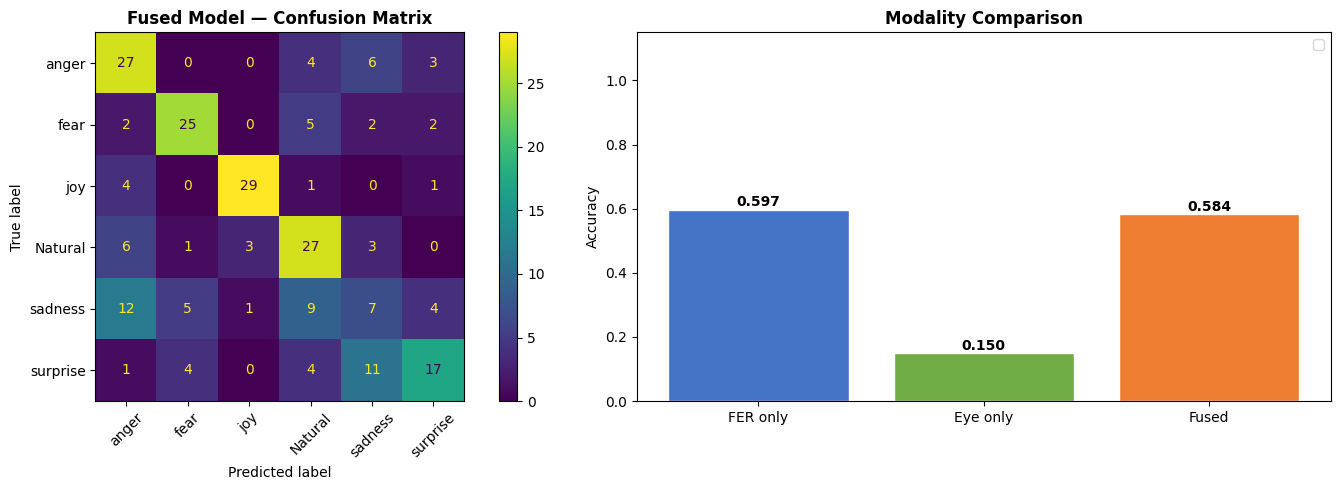


Saved fusion results to Autism emotion recognition dataset/results/lateFusion/fusion_results.png


In [16]:
# Confusion matrix
cm  = confusion_matrix(all_true, all_fused_preds)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay(cm, display_labels=EMOTIONS).plot(
    ax=axes[0], colorbar=True, xticks_rotation=45
)
axes[0].set_title('Fused Model — Confusion Matrix', fontweight='bold')

# Accuracy comparison bar
model_names = ['FER only', 'Eye only', 'Fused']
accs        = [fer_acc, eye_acc, fused_acc]
colours     = ['#4472C4', '#70AD47', '#ED7D31']
bars = axes[1].bar(model_names, accs, color=colours, edgecolor='white')
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Modality Comparison', fontweight='bold')
# axes[1].axhline(1/NUM_CLASSES, color='grey', linestyle='--', )
axes[1].legend()
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.01,
                 f'{acc:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fusion_results.png'), dpi=150)
plt.show()

print(f'\nSaved fusion results to {OUTPUT_DIR}/fusion_results.png')